# Autoencoder vs Standard Dimensionality Reduction

Compare what our autoencoder learns (m=2 bottleneck) with UMAP, t-SNE, and parallel coordinates on the same sparse data.

**Key question**: The autoencoder optimizes for reconstruction fidelity. UMAP/t-SNE optimize for preserving neighborhood structure (local distances). How do the resulting 2D maps differ, and what does each one reveal about the sparse feature geometry?

**Hypothesis**: The autoencoder should learn "superposition" (packing n>2 features into 2D via interference patterns), while distance-preserving methods should show cluster/manifold structure. The comparison should highlight that reconstruction != distance preservation.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

try:
    import umap
    HAS_UMAP = True
except ImportError:
    print("Install umap-learn: pip install umap-learn")
    HAS_UMAP = False

from core import (
    Autoencoder, generate_sparse_data, train_autoencoder,
    run_experiment_multi_seed, device
)

print(f"Device: {device}")
print(f"UMAP available: {HAS_UMAP}")

Device: cpu
UMAP available: True


## 1. Train autoencoders and generate shared data

In [2]:
# Config
configs = [
    {'n': 5, 'm': 2, 'l': 1, 'label': 'n=5, l=1 (linear)'},
    {'n': 5, 'm': 2, 'l': 3, 'label': 'n=5, l=3 (deep)'},
    {'n': 16, 'm': 2, 'l': 1, 'label': 'n=16, l=1 (linear)'},
    {'n': 16, 'm': 2, 'l': 3, 'label': 'n=16, l=3 (deep)'},
]
S = 0.95
n_viz = 2000  # samples for visualization

# Train autoencoders
results = {}
for cfg in configs:
    key = cfg['label']
    print(f"\n{'='*60}")
    print(f"Training: {key}")
    res = run_experiment_multi_seed(
        n=cfg['n'], m=cfg['m'], l=cfg['l'],
        S=S, n_seeds=10, n_steps=10000,
        importance_decay=0.7,
        verbose=True
    )
    results[key] = res
    print(f"  nonlinear_gain={res['nonlinear_gain']:.4f}")


Training: n=5, l=1 (linear)

Multi-seed experiment: n=5, m=2, l=1, S=0.95, n_seeds=10
Using importance weighting: I_i = 0.7^i


Seeds:   0%|          | 0/10 [00:00<?, ?it/s]

Seeds:   0%|          | 0/10 [00:02<?, ?it/s, loss=0.0010, min_norm=0.00, min_angle=6°]

Seeds:  10%|█         | 1/10 [00:02<00:25,  2.81s/it, loss=0.0010, min_norm=0.00, min_angle=6°]

Seeds:  10%|█         | 1/10 [00:04<00:25,  2.81s/it, loss=0.0010, min_norm=0.00, min_angle=11°]

...

Seeds:  90%|█████████ | 9/10 [00:39<00:04,  4.38s/it, loss=0.0004, min_norm=0.03, min_angle=29°]

Seeds:  90%|█████████ | 9/10 [00:43<00:04,  4.38s/it, loss=0.0016, min_norm=0.07, min_angle=21°]

Seeds: 100%|██████████| 10/10 [00:43<00:00,  4.33s/it, loss=0.0016, min_norm=0.07, min_angle=21°]

Seeds: 100%|██████████| 10/10 [00:43<00:00,  4.37s/it, loss=0.0016, min_norm=0.07, min_angle=21°]


Best seed: 3, loss: 0.000264
Seeds tried: 10/10
Loss range across seeds: [0.000264, 0.002198]
Geometry: min_norm=0.061, min_angle=36.5°
Results: linearity=0.986, nonlinear_gain=0.217
  nonlinear_gain=0.2168


In [3]:
# Generate shared datasets for each n value (same data for all methods)
datasets = {}
for n in set(cfg['n'] for cfg in configs):
    torch.manual_seed(42)
    x = generate_sparse_data(n_viz, n, S)
    datasets[n] = x.cpu().numpy()
    print(f"n={n}: generated {n_viz} samples, mean sparsity = {(x == 0).float().mean():.3f}")

n=16: generated 2000 samples, mean sparsity = 0.948
n=5: generated 2000 samples, mean sparsity = 0.950


## 2. Compute all 2D embeddings

In [4]:
def compute_all_embeddings(x_np, model, label):
    """Compute t-SNE, UMAP, and autoencoder 2D embeddings for the same data."""
    embeddings = {}
    
    # Autoencoder
    model.eval()
    with torch.no_grad():
        x_t = torch.tensor(x_np, dtype=torch.float32, device=device)
        z_ae = model.encode(x_t).cpu().numpy()
        x_recon = model.decode(model.encode(x_t)).cpu().numpy()
    ae_mse = np.mean((x_np - x_recon)**2, axis=1)
    embeddings['Autoencoder'] = {'z': z_ae, 'recon_err': ae_mse}
    
    # t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_tsne = tsne.fit_transform(x_np)
    embeddings['t-SNE'] = {'z': z_tsne}
    
    # UMAP
    if HAS_UMAP:
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
        z_umap = reducer.fit_transform(x_np)
        embeddings['UMAP'] = {'z': z_umap}
    
    return embeddings

# Compute embeddings for each config
all_embeddings = {}
for cfg in configs:
    key = cfg['label']
    x_np = datasets[cfg['n']]
    model = results[key]['model']
    print(f"Computing embeddings for {key}...")
    all_embeddings[key] = compute_all_embeddings(x_np, model, key)
print("Done.")

Computing embeddings for n=5, l=1 (linear)...


Computing embeddings for n=5, l=3 (deep)...


Computing embeddings for n=16, l=1 (linear)...


Computing embeddings for n=16, l=3 (deep)...


Done.


## 3. Side-by-side comparison: scatter plots

Color by number of active features (input sparsity pattern) — this is the most natural "ground truth" structure in this data.

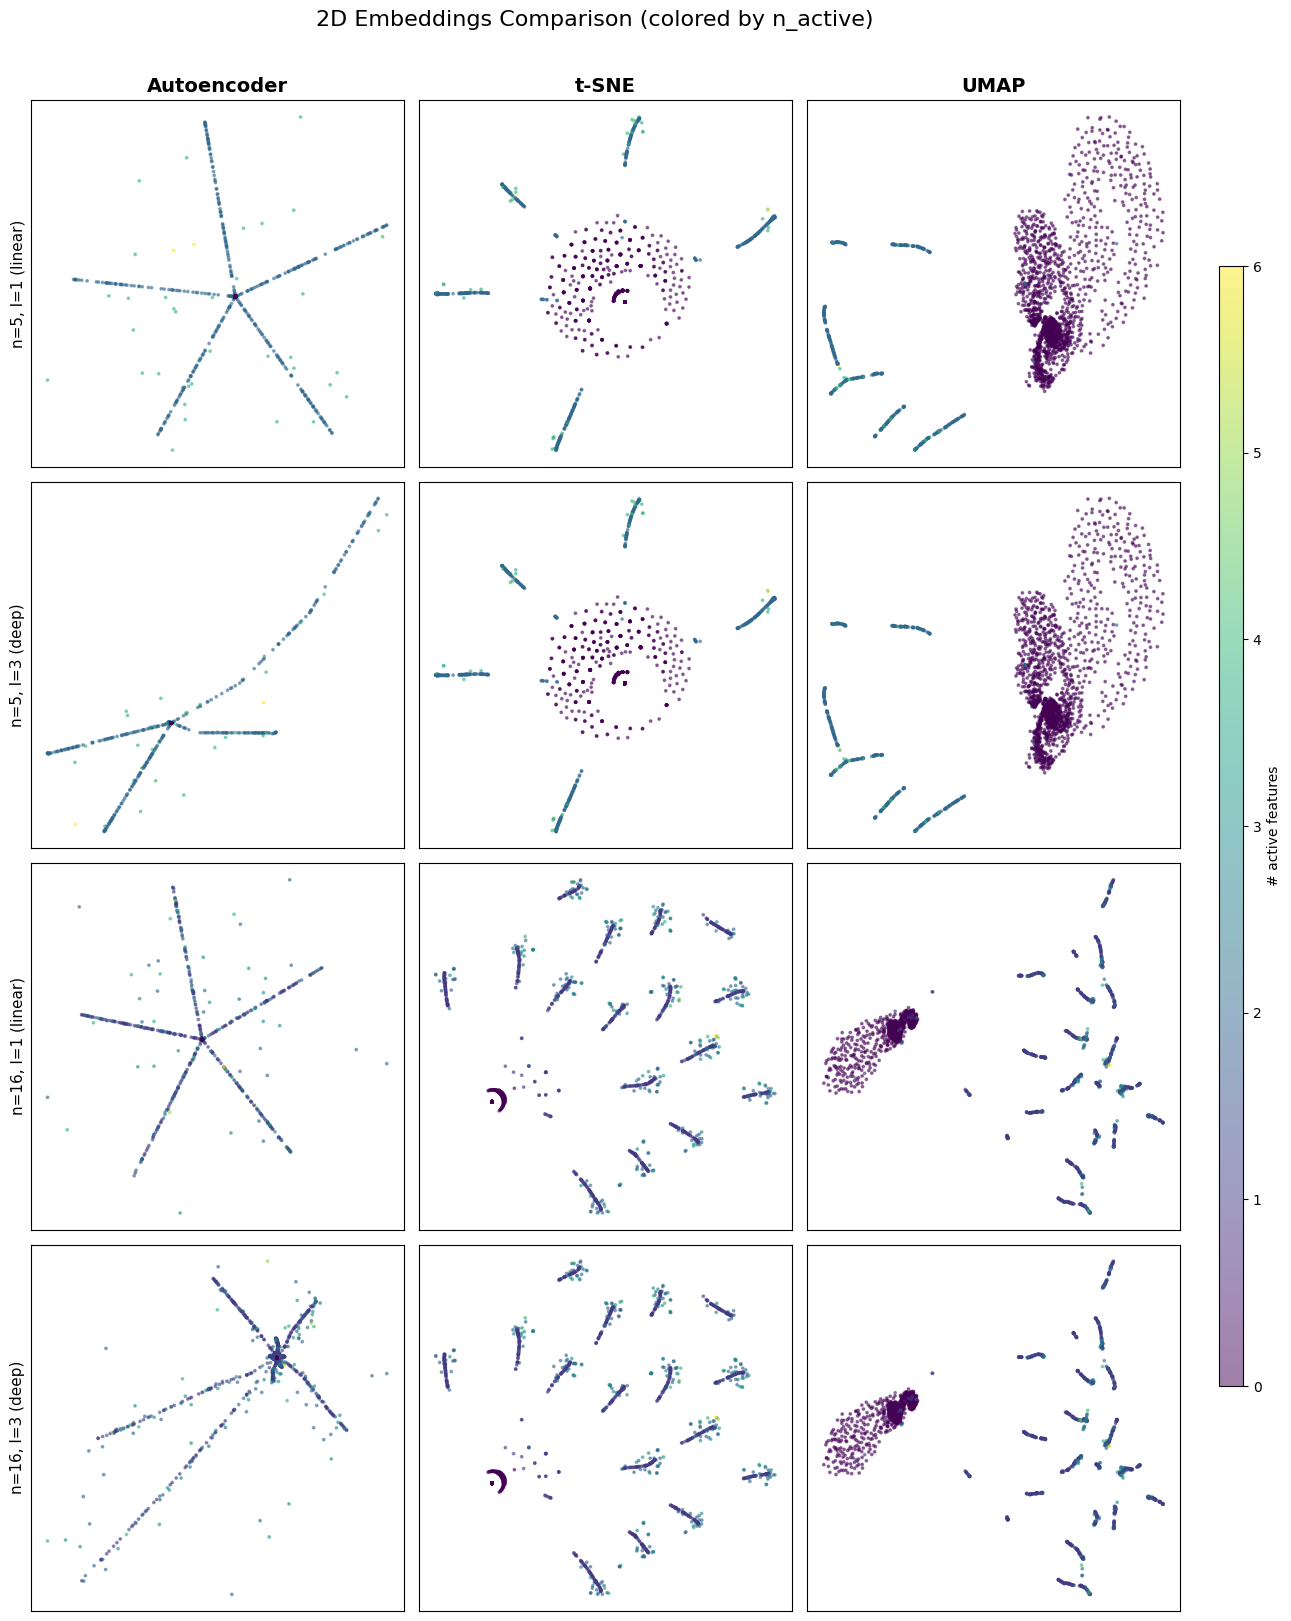

In [5]:
def get_feature_colors(n):
    """Get n distinct, saturated colors that won't be confused with gray."""
    # Use hsv to get maximally distinct, saturated colors
    return [plt.cm.hsv(i / n) for i in range(n)]

def plot_comparison_grid(configs, all_embeddings, datasets, color_by='n_active'):
    """Side-by-side scatter plots: rows = configs, cols = methods."""
    methods = ['Autoencoder', 't-SNE']
    if HAS_UMAP:
        methods.append('UMAP')
    
    n_rows = len(configs)
    n_cols = len(methods)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    
    for i, cfg in enumerate(configs):
        key = cfg['label']
        x_np = datasets[cfg['n']]
        n = cfg['n']
        
        for j, method in enumerate(methods):
            ax = axes[i, j]
            emb = all_embeddings[key][method]
            z = emb['z']
            
            if color_by == 'n_active':
                c = (x_np > 0).sum(axis=1)
                sc = ax.scatter(z[:, 0], z[:, 1], c=c, cmap='viridis', s=3, alpha=0.5, rasterized=True)
            elif color_by == 'norm':
                c = np.linalg.norm(x_np, axis=1)
                sc = ax.scatter(z[:, 0], z[:, 1], c=c, cmap='plasma', s=3, alpha=0.5, rasterized=True)
            elif color_by == 'dominant_feature':
                is_zero = x_np.sum(axis=1) == 0
                colors_feat = get_feature_colors(n)
                # Plot zeros in black
                if is_zero.sum() > 0:
                    ax.scatter(z[is_zero, 0], z[is_zero, 1], c='black',
                              s=3, alpha=0.3, rasterized=True, label='zero')
                # Plot each feature
                dominant = np.argmax(x_np, axis=1)
                for fi in range(n):
                    mask = (~is_zero) & (dominant == fi)
                    if mask.sum() > 0:
                        ax.scatter(z[mask, 0], z[mask, 1], c=[colors_feat[fi]],
                                  s=5, alpha=0.5, rasterized=True, label=f'f{fi}')
                sc = None
                # Add legend to rightmost column
                if j == n_cols - 1:
                    ax.legend(fontsize=5, loc='upper left', bbox_to_anchor=(1.02, 1),
                             ncol=1, markerscale=2, framealpha=0.8)
            
            if i == 0:
                ax.set_title(method, fontsize=14, fontweight='bold')
            if j == 0:
                ax.set_ylabel(key, fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])
    
    clabels = {'n_active': '# active features', 'norm': 'input norm'}
    fig.suptitle(f'2D Embeddings Comparison (colored by {color_by})', fontsize=16, y=1.01)
    plt.tight_layout()
    if color_by in clabels:
        cbar_ax = fig.add_axes([1.02, 0.15, 0.02, 0.7])
        fig.colorbar(sc, cax=cbar_ax, label=clabels[color_by])
    plt.show()

plot_comparison_grid(configs, all_embeddings, datasets, color_by='n_active')

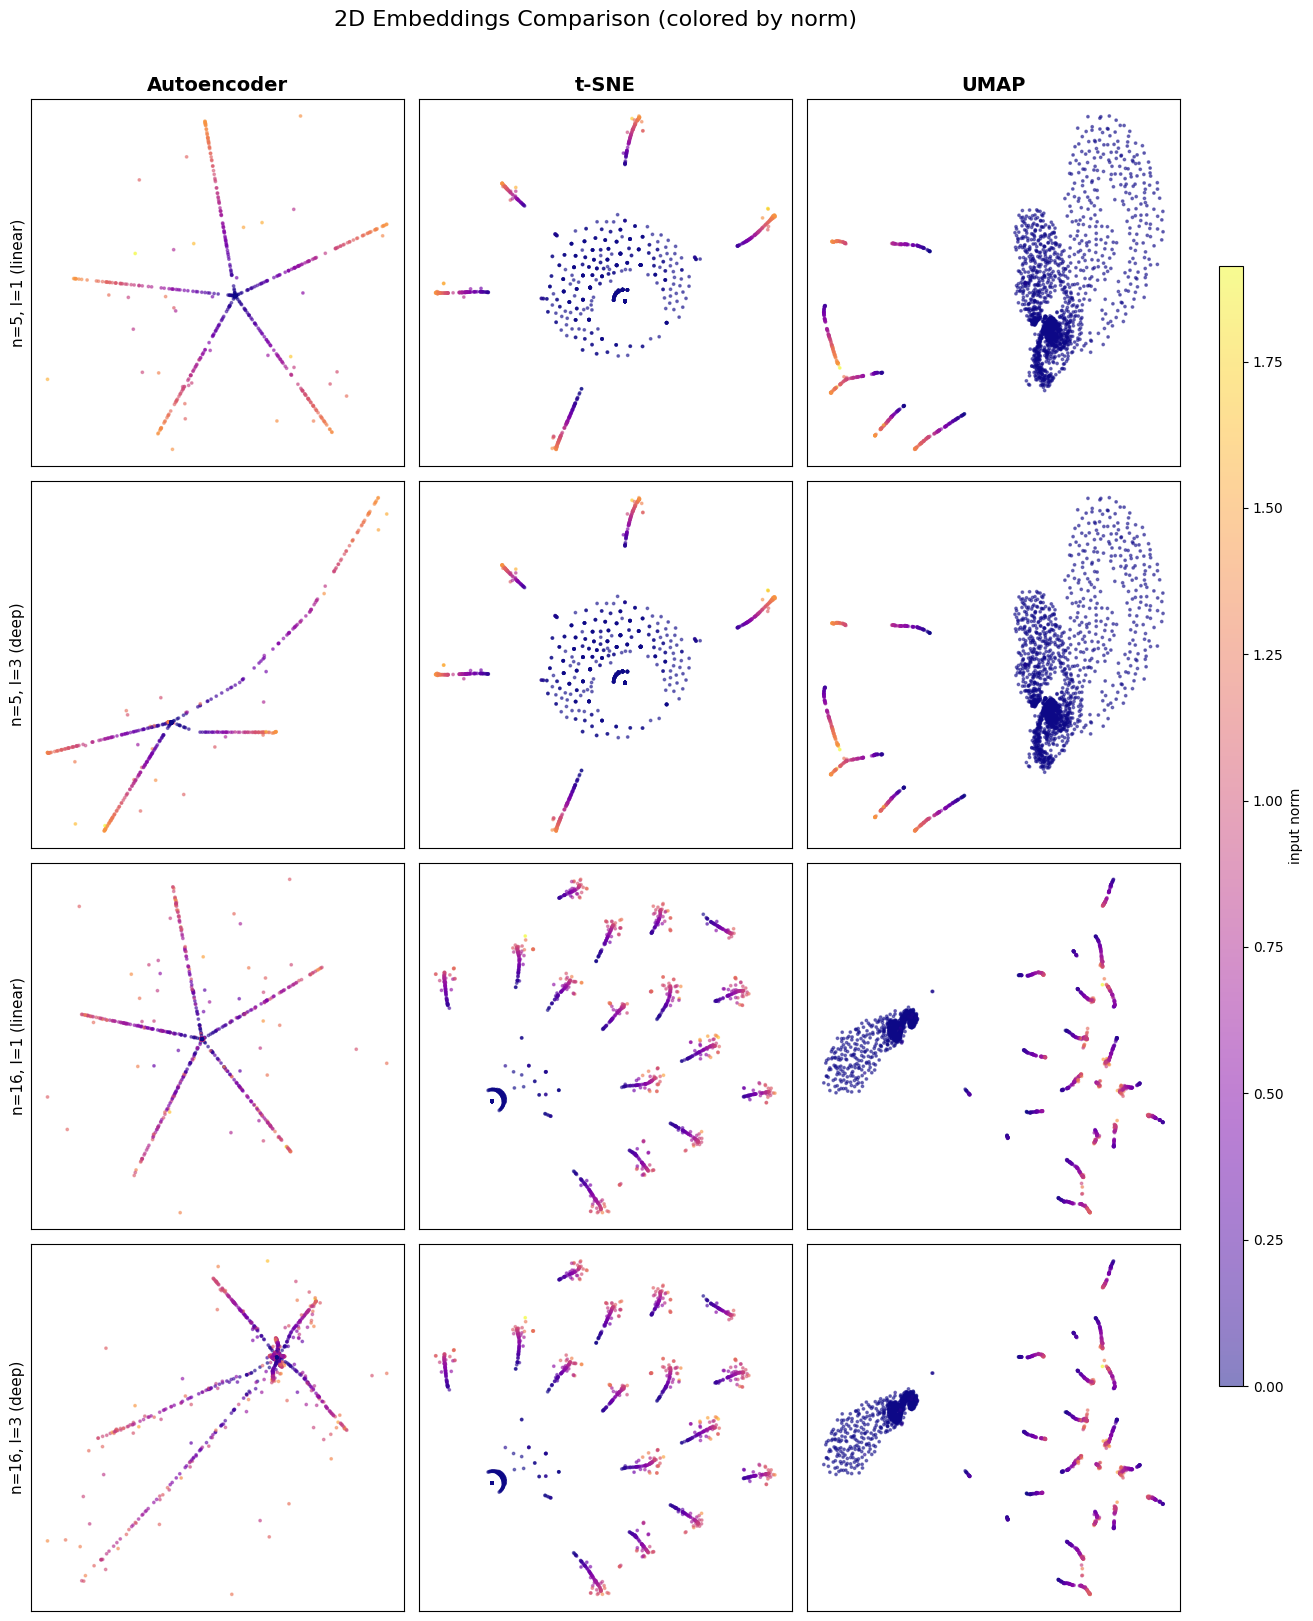

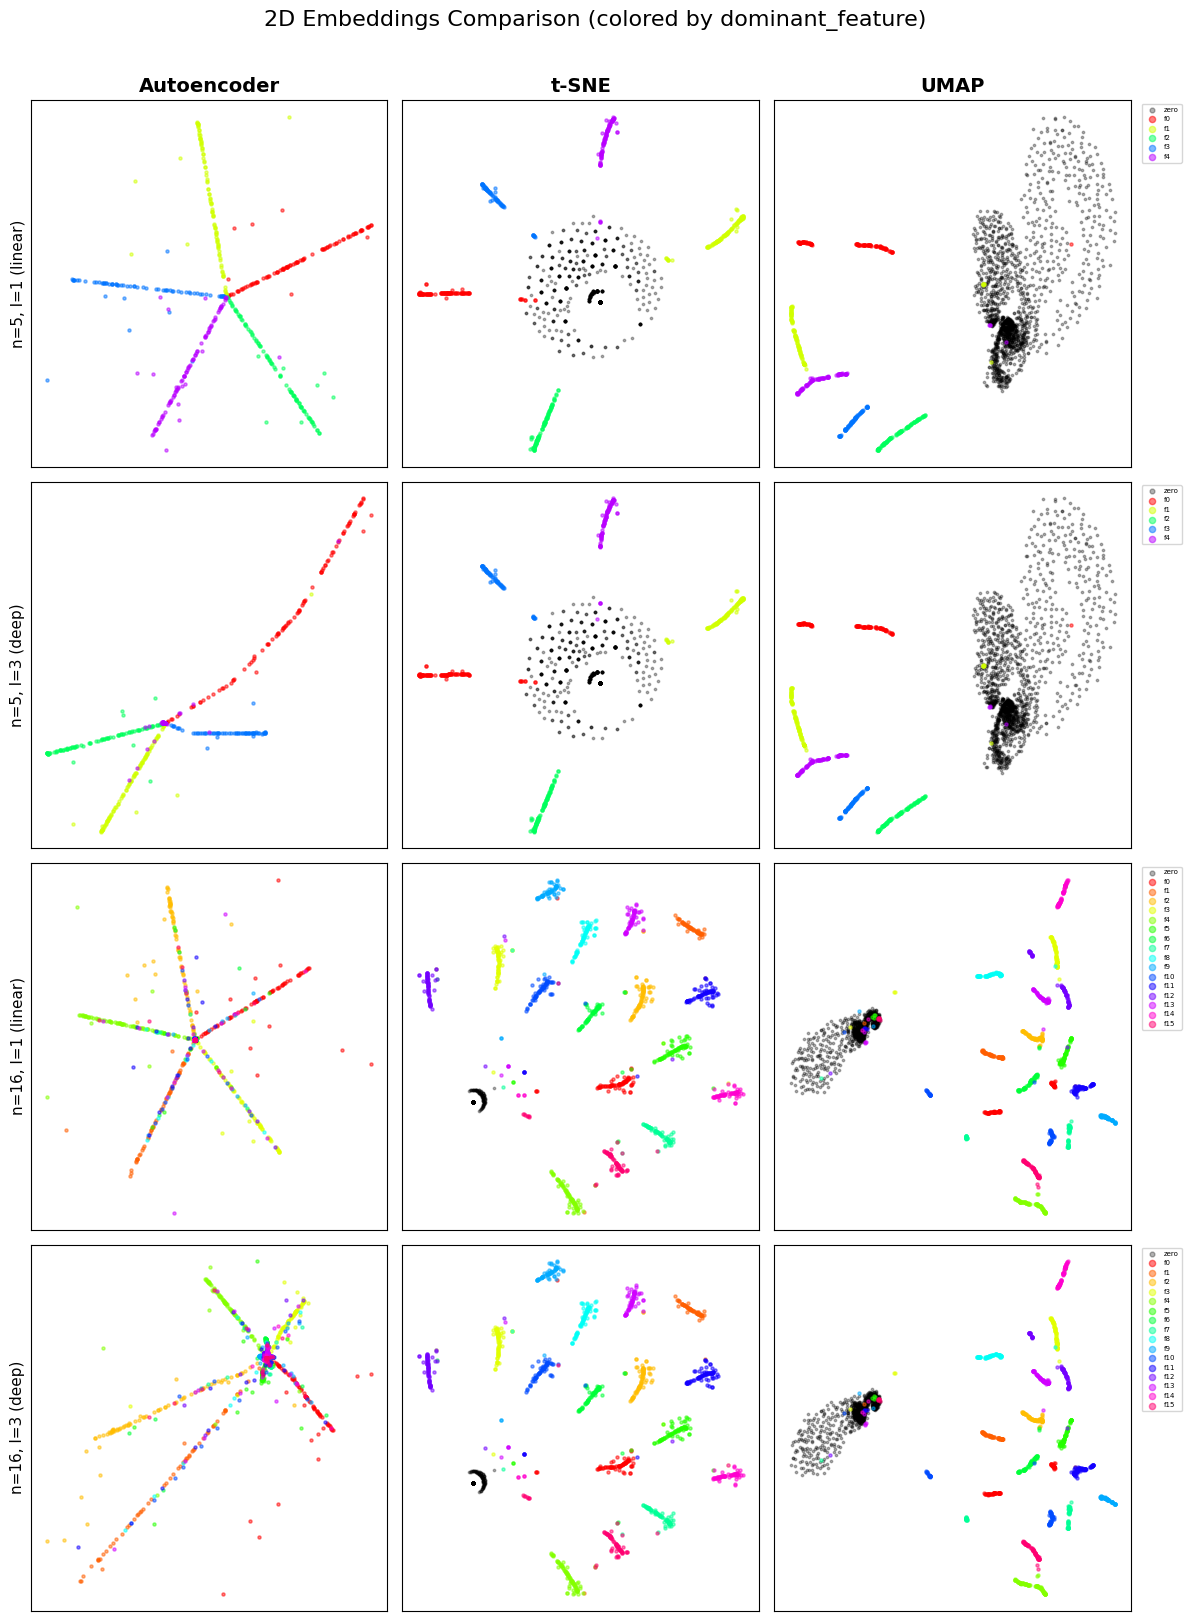

In [6]:
# Same comparison colored by input norm
plot_comparison_grid(configs, all_embeddings, datasets, color_by='norm')

# Same comparison colored by dominant feature (gray = zero vector)
plot_comparison_grid(configs, all_embeddings, datasets, color_by='dominant_feature')

## 3b. Non-zero samples only

At S=0.95, a large fraction of samples are the all-zero vector (0.95^n): 77% for n=5, 43% for n=16. These dominate the scatter plots and obscure the interesting structure. Here we filter to non-zero samples only and compare methods colored by dominant feature identity and by number of active features.

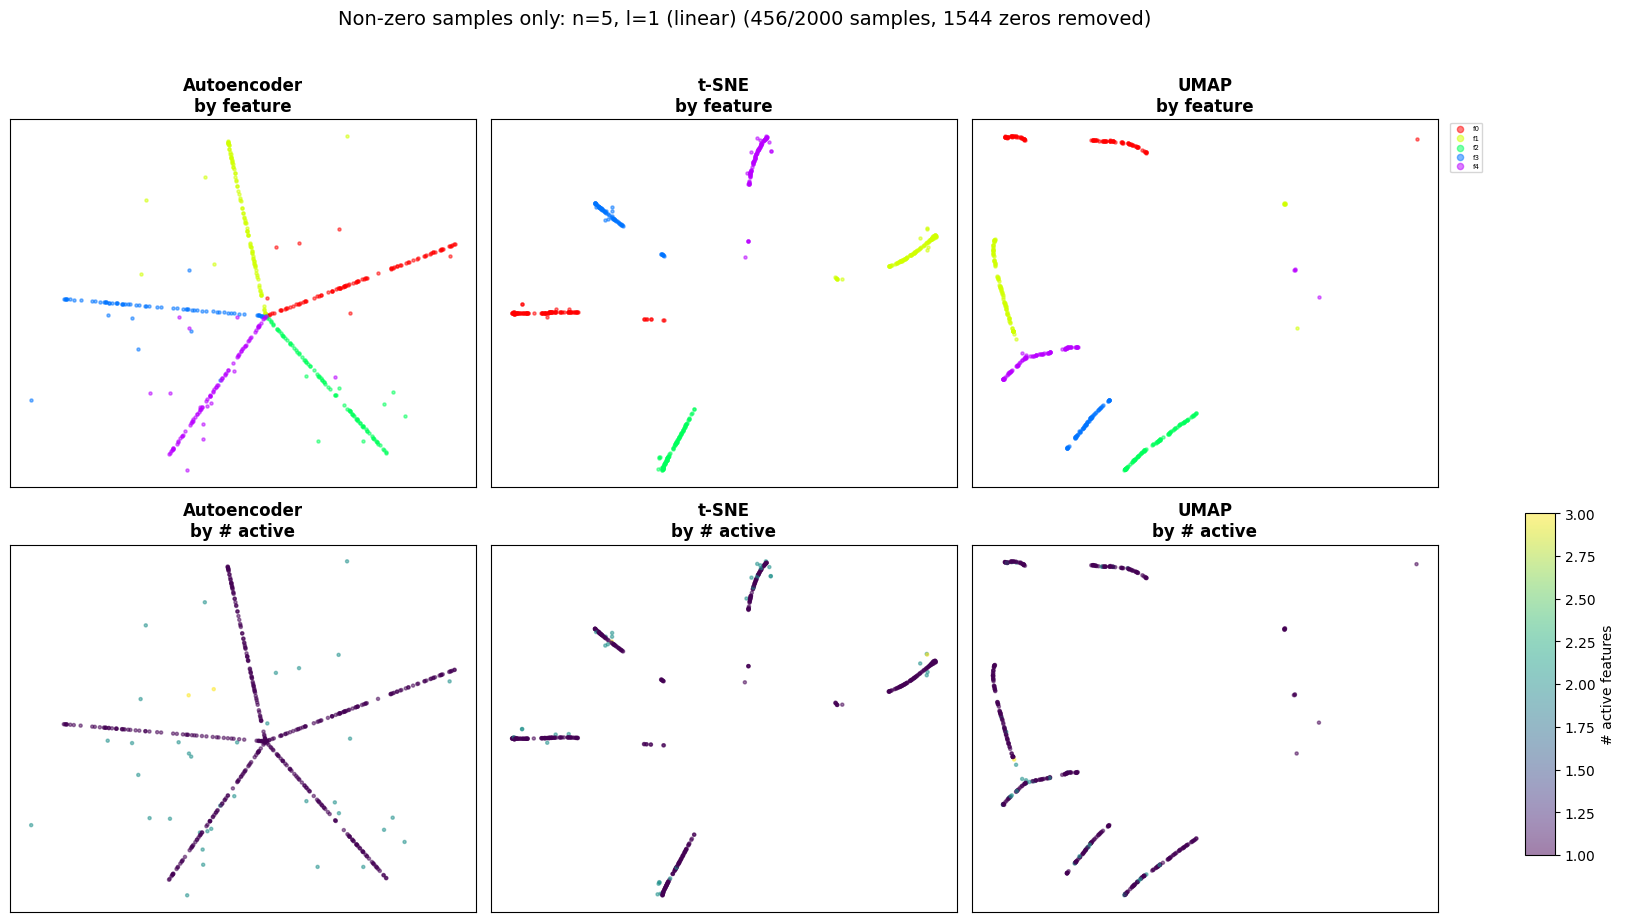

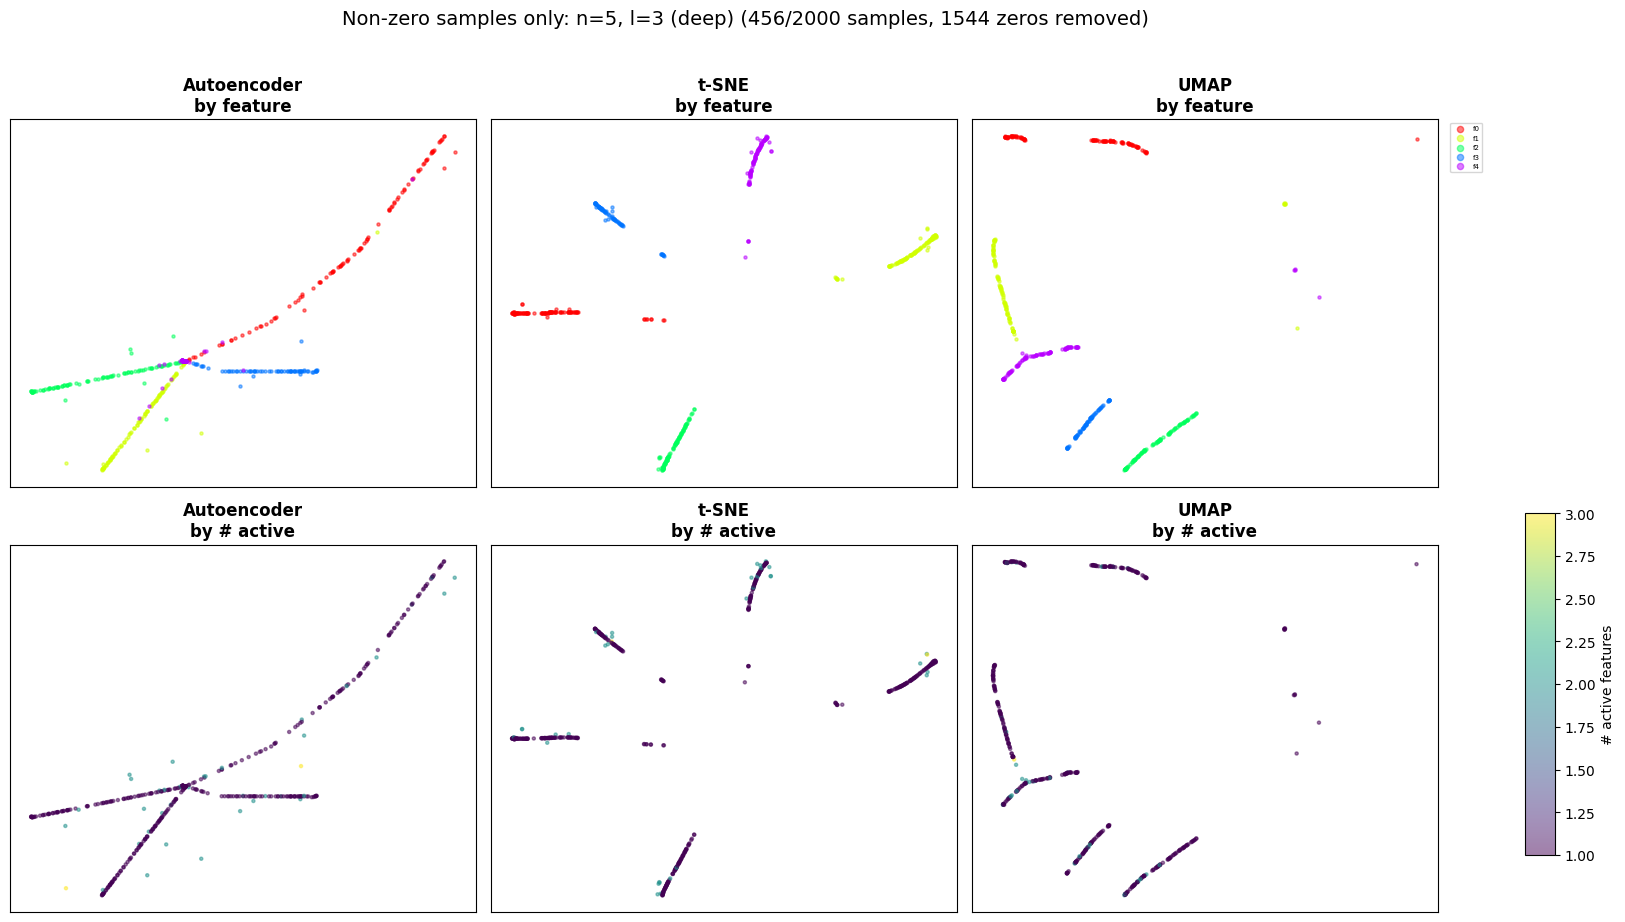

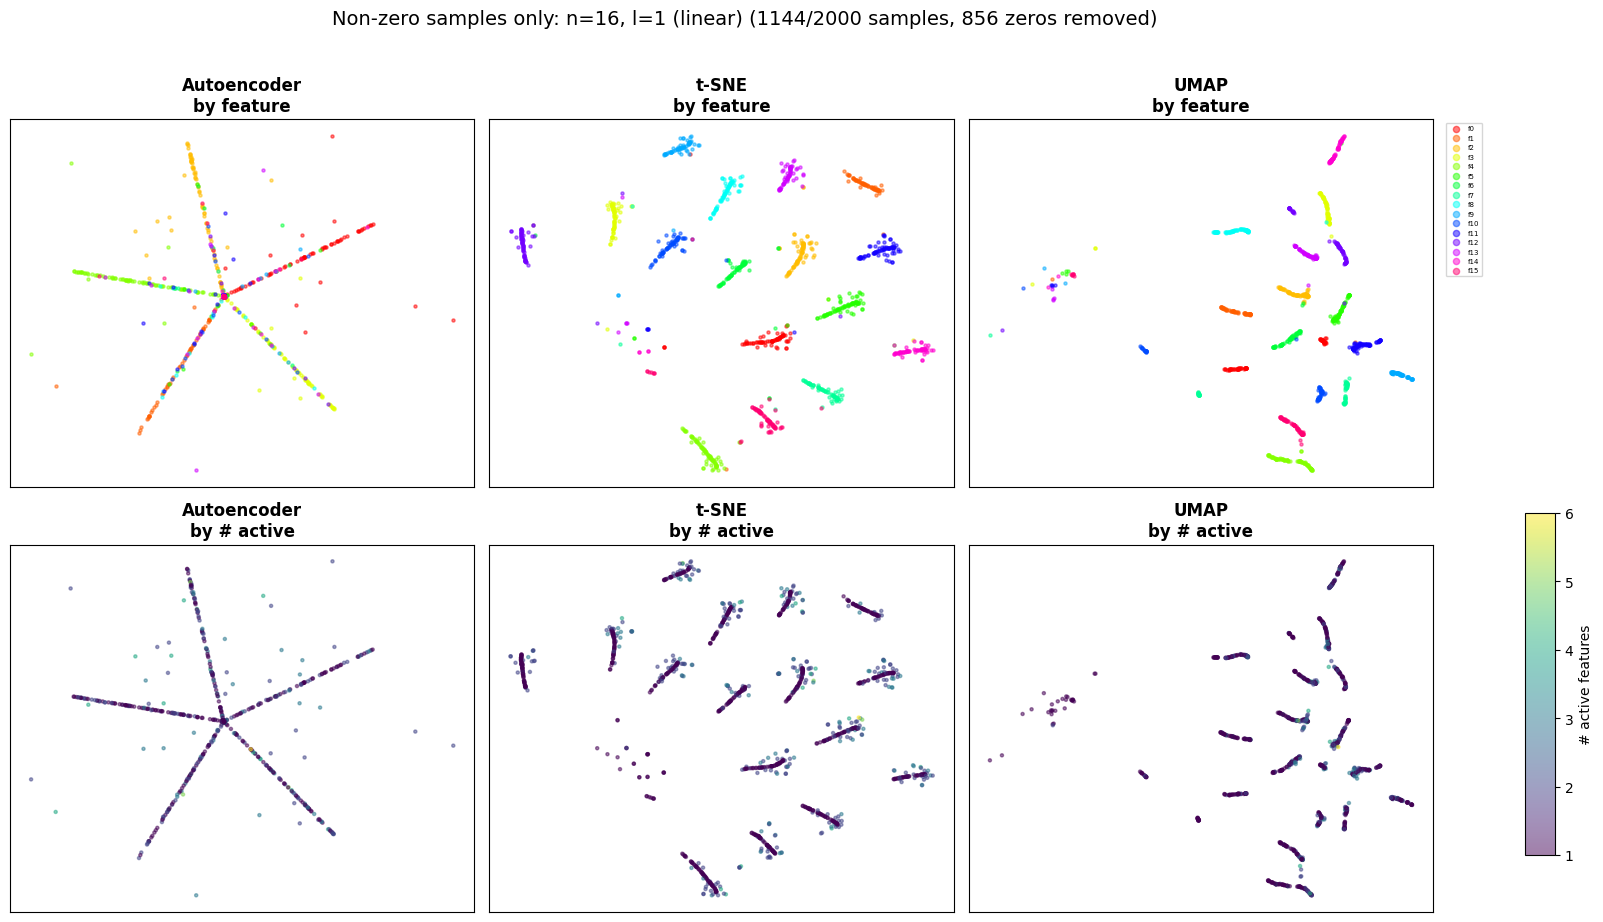

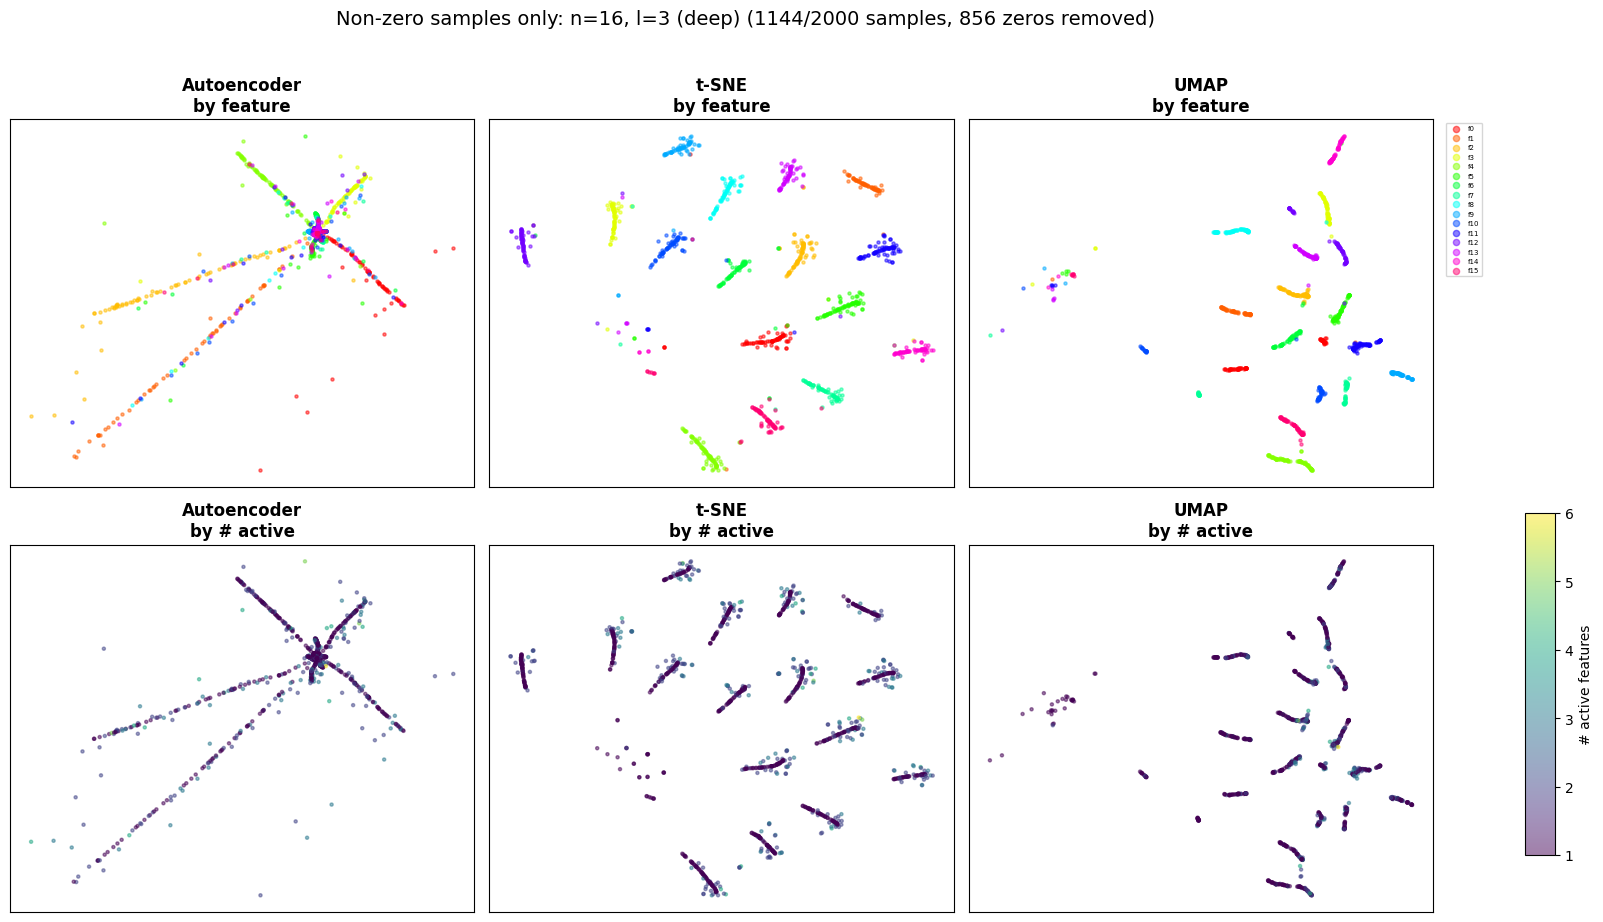

In [7]:
def plot_nonzero_comparison(configs_subset, all_embeddings, datasets):
    """Scatter plots of non-zero samples only, colored by dominant feature and by # active."""
    methods = ['Autoencoder', 't-SNE']
    if HAS_UMAP:
        methods.append('UMAP')
    
    for cfg in configs_subset:
        key = cfg['label']
        n = cfg['n']
        x_np = datasets[n]
        
        # Filter to non-zero samples
        nz_mask = x_np.sum(axis=1) > 0
        x_nz = x_np[nz_mask]
        n_total = len(x_np)
        n_nz = nz_mask.sum()
        n_zero = n_total - n_nz
        
        # Dominant feature (argmax of input)
        dominant_feature = np.argmax(x_nz, axis=1)
        n_active = (x_nz > 0).sum(axis=1)
        
        n_methods = len(methods)
        fig, axes = plt.subplots(2, n_methods, figsize=(5 * n_methods, 9))
        
        colors_feat = get_feature_colors(n)
        
        for j, method in enumerate(methods):
            z_full = all_embeddings[key][method]['z']
            z_nz = z_full[nz_mask]
            
            # Top row: colored by dominant feature
            ax = axes[0, j]
            for fi in range(n):
                mask_fi = dominant_feature == fi
                if mask_fi.sum() > 0:
                    ax.scatter(z_nz[mask_fi, 0], z_nz[mask_fi, 1],
                              c=[colors_feat[fi]], s=5, alpha=0.5, label=f'f{fi}')
            ax.set_title(f'{method}\nby feature', fontsize=12, fontweight='bold')
            ax.set_xticks([])
            ax.set_yticks([])
            # Add legend to rightmost column
            if j == n_methods - 1:
                ax.legend(fontsize=5, loc='upper left', bbox_to_anchor=(1.02, 1),
                         ncol=1, markerscale=2, framealpha=0.8)
            
            # Bottom row: colored by # active features
            ax2 = axes[1, j]
            sc = ax2.scatter(z_nz[:, 0], z_nz[:, 1], c=n_active,
                           cmap='viridis', s=5, alpha=0.5)
            ax2.set_title(f'{method}\nby # active', fontsize=12, fontweight='bold')
            ax2.set_xticks([])
            ax2.set_yticks([])
        
        fig.suptitle(f'Non-zero samples only: {key} ({n_nz}/{n_total} samples, {n_zero} zeros removed)',
                    fontsize=14, y=1.02)
        plt.tight_layout()
        cbar_ax = fig.add_axes([1.02, 0.08, 0.02, 0.38])
        fig.colorbar(sc, cax=cbar_ax, label='# active features')
        plt.show()

# Show for all configs (both n=5 and n=16)
plot_nonzero_comparison(configs, all_embeddings, datasets)

In [8]:
# Investigate: what does t-SNE's neighborhood look like for low vs high magnitude points?
# Pick n=16, l=1 config

x_np = datasets[16]
nz_mask = x_np.sum(axis=1) > 0
x_nz = x_np[nz_mask]
n_active = (x_nz > 0).sum(axis=1)
dominant = np.argmax(x_nz, axis=1)
magnitudes = np.linalg.norm(x_nz, axis=1)

# Look at single-feature samples only
single_mask = n_active == 1
x_single = x_nz[single_mask]
dom_single = dominant[single_mask]
mag_single = magnitudes[single_mask]

# For a low-magnitude single-feature point, what are its nearest neighbors?
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=31).fit(x_nz)

# Pick the lowest-magnitude single-feature point for feature 0
f0_mask = dom_single == 0
f0_mags = mag_single[f0_mask]
low_idx = np.argmin(f0_mags)
high_idx = np.argmax(f0_mags)

# Map back to x_nz indices
single_indices = np.where(single_mask)[0]
f0_indices = single_indices[np.where(f0_mask)[0]]

for label, idx in [('LOW mag f0', f0_indices[low_idx]), ('HIGH mag f0', f0_indices[high_idx])]:
    point = x_nz[idx]
    mag = np.linalg.norm(point)
    dists, nbr_idx = nn.kneighbors(point.reshape(1, -1))
    nbr_idx = nbr_idx[0, 1:]  # exclude self
    dists = dists[0, 1:]
    
    nbr_n_active = n_active[nbr_idx]
    nbr_dominant = dominant[nbr_idx]
    nbr_is_zero_like = magnitudes[nbr_idx] < 0.1
    
    print(f"\n{label} (magnitude={mag:.3f}, point={point.round(3)})")
    print(f"  30 nearest neighbors:")
    print(f"    Same feature (f0): {(nbr_dominant == 0).sum()}")
    print(f"    Different feature: {(nbr_dominant != 0).sum()}")
    print(f"    Single-feature neighbors: {(nbr_n_active[None] == 1).sum() if nbr_n_active.ndim == 1 else 'err'}")
    print(f"    Multi-feature neighbors: {(nbr_n_active > 1).sum()}")
    print(f"    Mean neighbor distance: {dists.mean():.4f}")
    print(f"    Distance range: [{dists.min():.4f}, {dists.max():.4f}]")
    
    # What features are represented?
    from collections import Counter
    feat_counts = Counter(nbr_dominant[nbr_n_active == 1].tolist())
    print(f"    Single-feature neighbor breakdown: {dict(feat_counts)}")


LOW mag f0 (magnitude=0.007, point=[0.007 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.   ])
  30 nearest neighbors:
    Same feature (f0): 2
    Different feature: 28
    Single-feature neighbors: 30
    Multi-feature neighbors: 0
    Mean neighbor distance: 0.0230
    Distance range: [0.0035, 0.0443]
    Single-feature neighbor breakdown: {0: 2, 15: 4, 7: 1, 9: 2, 3: 3, 13: 1, 5: 3, 10: 2, 8: 3, 14: 2, 4: 2, 2: 2, 1: 1, 11: 2}

HIGH mag f0 (magnitude=0.986, point=[0.986 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.   ])
  30 nearest neighbors:
    Same feature (f0): 30
    Different feature: 0
    Single-feature neighbors: 27
    Multi-feature neighbors: 3
    Mean neighbor distance: 0.2942
    Distance range: [0.0088, 0.5007]
    Single-feature neighbor breakdown: {0: 27}


## 4. Feature trajectory comparison

For each input feature $e_i$, trace $\text{embed}(t \cdot e_i)$ as $t$ goes from 0 to 1.5. The autoencoder (with ReLU, no bias) gives perfectly straight lines (positive homogeneity) for l=1, curved for l>1. How do UMAP/t-SNE handle this?

Note: t-SNE and UMAP don't have a natural `transform` for new points, so we'll refit including the trajectory points — this is a known limitation but still informative.

Computing trajectories for n=5, l=1 (linear)...


Computing trajectories for n=5, l=3 (deep)...


Computing trajectories for n=16, l=1 (linear)...


Computing trajectories for n=16, l=3 (deep)...


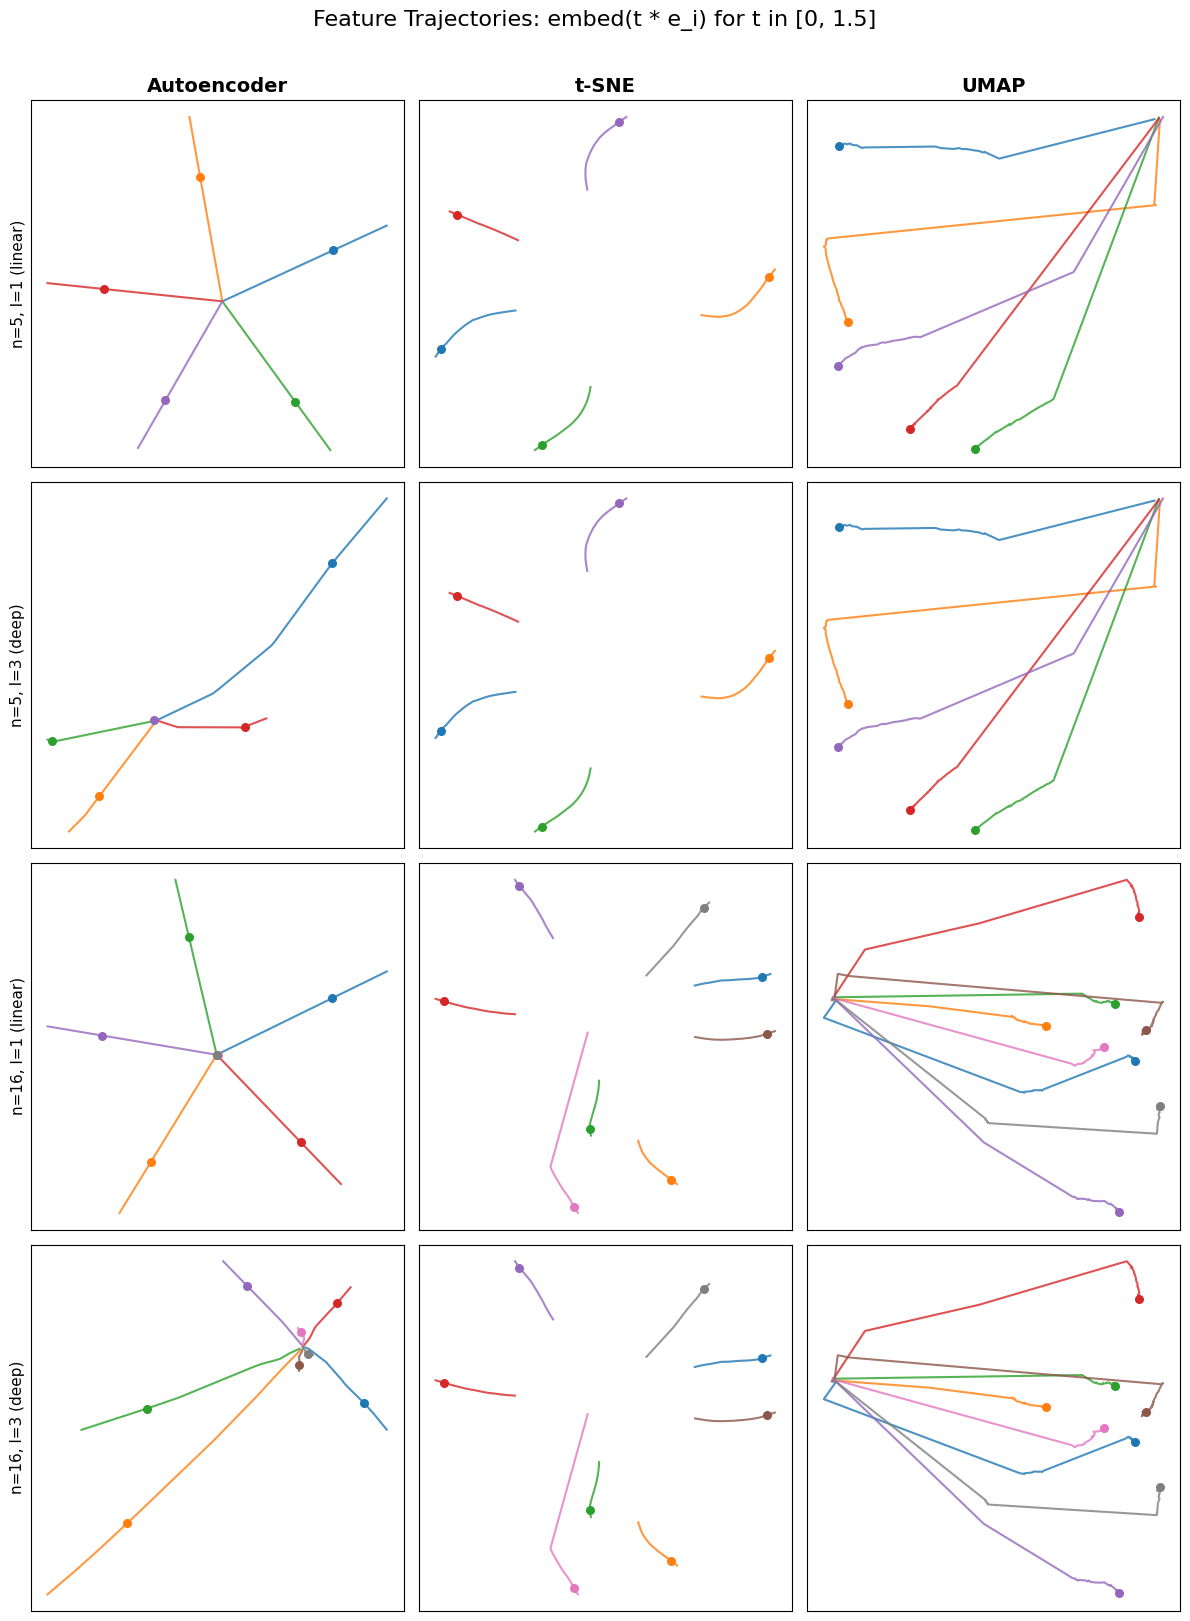

In [9]:
def compute_feature_trajectories(n, model, n_points=50):
    """Compute trajectory of each unit feature e_i scaled by t in [0, 1.5] through each method."""
    t_vals = np.linspace(0.01, 1.5, n_points)
    
    # Generate trajectory data: for each feature i, points are t * e_i
    all_traj_points = []  # (n_features * n_points, n)
    for i in range(n):
        for t in t_vals:
            point = np.zeros(n)
            point[i] = t
            all_traj_points.append(point)
    traj_np = np.array(all_traj_points, dtype=np.float32)
    
    trajectories = {}
    
    # Autoencoder trajectories
    model.eval()
    with torch.no_grad():
        traj_t = torch.tensor(traj_np, device=device)
        z_ae = model.encode(traj_t).cpu().numpy()
    trajectories['Autoencoder'] = z_ae.reshape(n, n_points, 2)
    
    # Background data for fitting
    torch.manual_seed(42)
    bg = generate_sparse_data(2000, n, 0.95).cpu().numpy()
    
    # t-SNE: fit on bg + trajectory points together
    combined = np.vstack([bg, traj_np])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    z_all = tsne.fit_transform(combined)
    z_tsne_traj = z_all[len(bg):]
    trajectories['t-SNE'] = z_tsne_traj.reshape(n, n_points, 2)
    
    # UMAP: use transform method
    if HAS_UMAP:
        reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
        reducer.fit(bg)
        z_umap_traj = reducer.transform(traj_np)
        trajectories['UMAP'] = z_umap_traj.reshape(n, n_points, 2)
    
    return trajectories, t_vals


def plot_trajectory_comparison(configs_subset, results, n_features_show=8):
    """Plot feature trajectories across methods for selected configs."""
    methods = ['Autoencoder', 't-SNE']
    if HAS_UMAP:
        methods.append('UMAP')
    
    n_rows = len(configs_subset)
    n_cols = len(methods)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for i, cfg in enumerate(configs_subset):
        key = cfg['label']
        model = results[key]['model']
        n = cfg['n']
        print(f"Computing trajectories for {key}...")
        trajs, t_vals = compute_feature_trajectories(n, model)
        
        n_show = min(n_features_show, n)
        
        for j, method in enumerate(methods):
            ax = axes[i, j]
            traj = trajs[method]
            
            for fi in range(n_show):
                ax.plot(traj[fi, :, 0], traj[fi, :, 1],
                       color=colors[fi % 10], linewidth=1.5, alpha=0.8)
                # Mark the t=1 point
                mid = len(t_vals) * 2 // 3
                ax.scatter(traj[fi, mid, 0], traj[fi, mid, 1],
                          color=colors[fi % 10], s=30, zorder=5)
            
            if i == 0:
                ax.set_title(method, fontsize=14, fontweight='bold')
            if j == 0:
                ax.set_ylabel(key, fontsize=11)
            ax.set_xticks([])
            ax.set_yticks([])
    
    fig.suptitle('Feature Trajectories: embed(t * e_i) for t in [0, 1.5]', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

plot_trajectory_comparison(configs, results)

## 5. Reconstruction fidelity comparison

The autoencoder directly optimizes reconstruction. UMAP can transform new points, so we can do a fair train/test split.

**Important**: t-SNE has no out-of-sample transform, so we cannot fairly evaluate it here — fitting t-SNE on all data and then splitting creates data leakage (test embeddings are informed by test inputs). t-SNE is excluded from this comparison.

In [10]:
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

def reconstruction_from_embedding(z_train, x_train, z_test, x_test):
    """Fit a small MLP decoder on z->x and measure reconstruction MSE."""
    # Linear decoder
    ridge = Ridge(alpha=1e-3)
    ridge.fit(z_train, x_train)
    pred_linear = ridge.predict(z_test)
    mse_linear = np.mean((x_test - pred_linear)**2)
    
    # Nonlinear decoder (small MLP)
    mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42,
                       early_stopping=True, validation_fraction=0.2)
    mlp.fit(z_train, x_train)
    pred_mlp = mlp.predict(z_test)
    mse_mlp = np.mean((x_test - pred_mlp)**2)
    
    return mse_linear, mse_mlp


def compare_reconstruction_quality(configs, all_embeddings, datasets):
    """For each method, train a decoder on train embeddings and evaluate on test.
    
    t-SNE is excluded: it has no out-of-sample transform, so splitting embeddings
    computed on all data would be data leakage.
    
    For AE/UMAP: fit embedding on train data, transform test data, then
    fit decoder on train embeddings -> train inputs.
    """
    # Methods with valid out-of-sample transforms
    methods = ['Autoencoder']
    if HAS_UMAP:
        methods.append('UMAP')
    
    print(f"{'Config':<25} {'Method':<12} {'MSE (linear dec)':<18} {'MSE (MLP dec)'}")
    print('-' * 75)
    print("(t-SNE excluded — no out-of-sample transform, would cause data leakage)")
    print()
    
    recon_results = []
    
    for cfg in configs:
        key = cfg['label']
        n = cfg['n']
        x_np = datasets[n]
        n_train = int(0.8 * len(x_np))
        x_train, x_test = x_np[:n_train], x_np[n_train:]
        
        for method in methods:
            # Compute proper train/test embeddings (no leakage)
            if method == 'Autoencoder':
                model = results[key]['model']
                model.eval()
                with torch.no_grad():
                    z_train = model.encode(torch.tensor(x_train, dtype=torch.float32, device=device)).cpu().numpy()
                    z_test_emb = model.encode(torch.tensor(x_test, dtype=torch.float32, device=device)).cpu().numpy()
                    x_recon_te = model(torch.tensor(x_test, dtype=torch.float32, device=device))[0].cpu().numpy()
                native_mse = np.mean((x_test - x_recon_te)**2)
            elif method == 'UMAP':
                reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
                z_train = reducer.fit_transform(x_train)
                z_test_emb = reducer.transform(x_test)
                native_mse = None
            
            mse_lin, mse_mlp = reconstruction_from_embedding(
                z_train, x_train, z_test_emb, x_test)
            
            native_str = f"  (native: {native_mse:.6f})" if native_mse is not None else ""
            print(f"{key:<25} {method:<12} {mse_lin:<18.6f} {mse_mlp:.6f}{native_str}")
            
            recon_results.append({
                'config': key, 'method': method,
                'mse_linear': mse_lin, 'mse_mlp': mse_mlp
            })
        print()
    
    return recon_results

recon_results = compare_reconstruction_quality(configs, all_embeddings, datasets)

Config                    Method       MSE (linear dec)   MSE (MLP dec)
---------------------------------------------------------------------------
(t-SNE excluded — no out-of-sample transform, would cause data leakage)

n=5, l=1 (linear)         Autoencoder  0.008050           0.000379  (native: 0.001019)


n=5, l=1 (linear)         UMAP         0.009501           0.000789

n=5, l=3 (deep)           Autoencoder  0.008764           0.003502  (native: 0.003815)


n=5, l=3 (deep)           UMAP         0.009501           0.000789

n=16, l=1 (linear)        Autoencoder  0.015007           0.012082  (native: 0.012200)


n=16, l=1 (linear)        UMAP         0.016015           0.010240



n=16, l=3 (deep)          Autoencoder  0.015142           0.008554  (native: 0.006556)


n=16, l=3 (deep)          UMAP         0.016015           0.010240



## 6. Neighborhood preservation comparison

Flip the script: the autoencoder optimizes reconstruction, but how well does it preserve local neighborhoods? Compare with t-SNE/UMAP which explicitly optimize for this.

**Caveat**: At S=0.95, the majority of samples are the zero vector (77% for n=5, 43% for n=16). All-zero samples trivially share neighbors in any embedding, inflating neighborhood preservation for methods that keep the origin compact (AE) and deflating scores for methods that spread points uniformly (t-SNE, UMAP). We show both all-data and non-zero-only results.

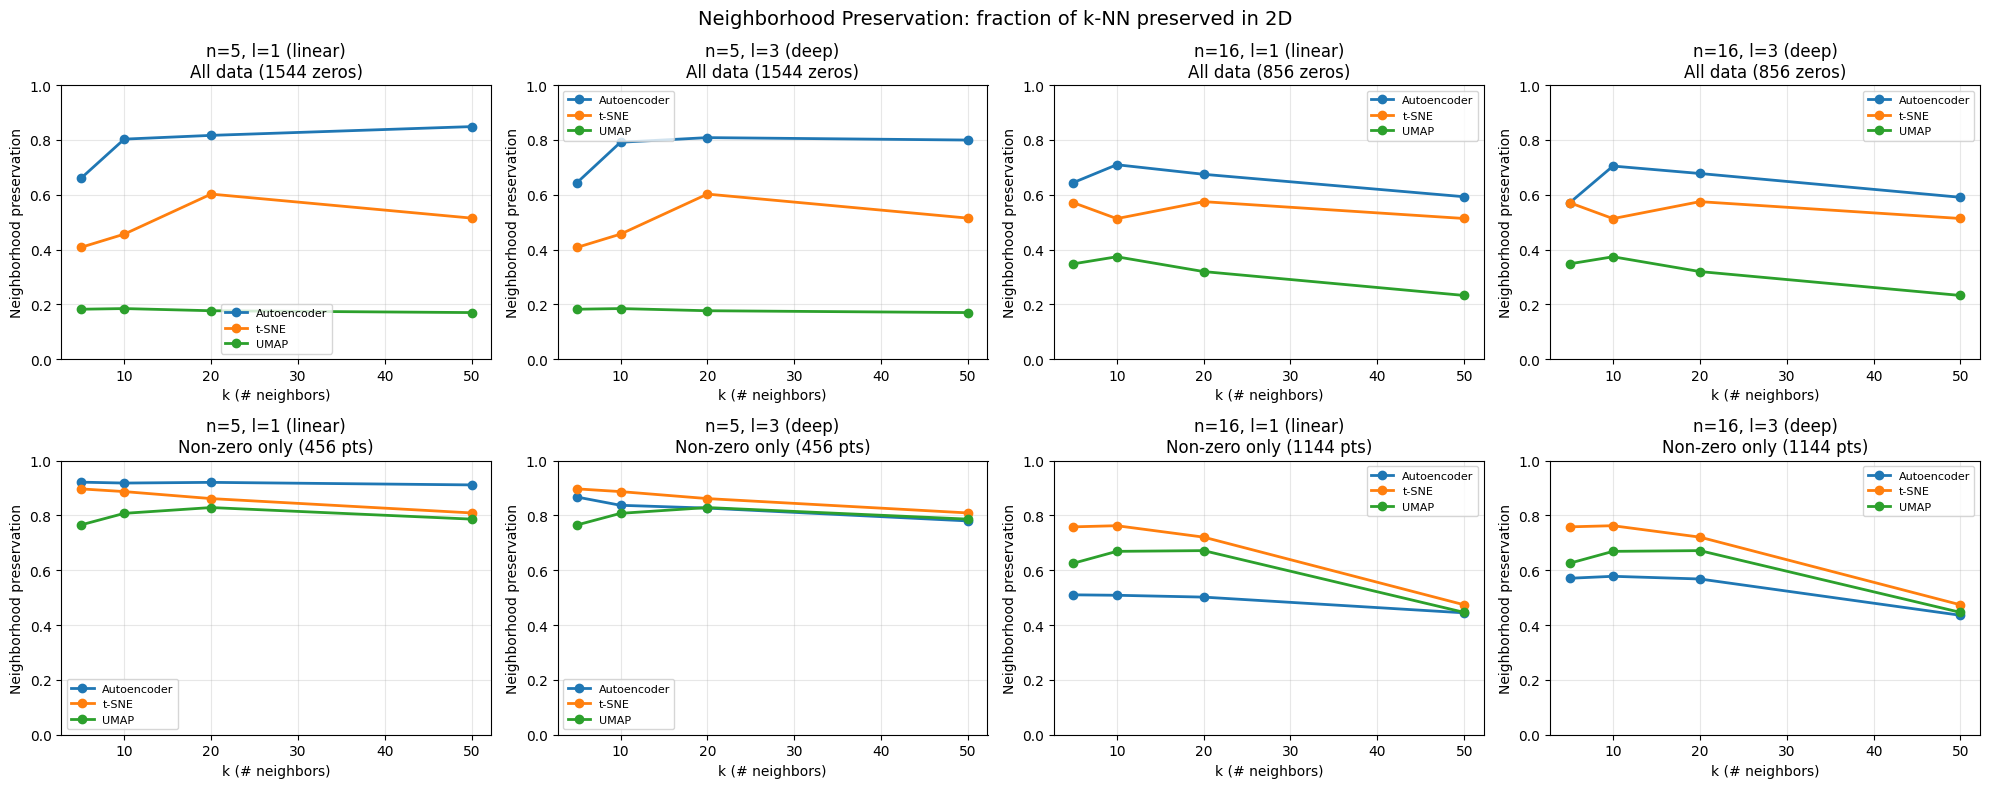

In [11]:
from sklearn.neighbors import NearestNeighbors

def neighborhood_preservation(x_np, z, k=10):
    """Fraction of k-nearest neighbors in input space that remain k-nearest in embedding."""
    n_samples = min(500, len(x_np))  # subsample for speed
    idx = np.random.RandomState(42).choice(len(x_np), n_samples, replace=False)
    x_sub = x_np[idx]
    z_sub = z[idx]
    
    nn_x = NearestNeighbors(n_neighbors=k+1).fit(x_sub)
    nn_z = NearestNeighbors(n_neighbors=k+1).fit(z_sub)
    
    _, idx_x = nn_x.kneighbors(x_sub)
    _, idx_z = nn_z.kneighbors(z_sub)
    
    # Exclude self (index 0)
    idx_x = idx_x[:, 1:]
    idx_z = idx_z[:, 1:]
    
    # Fraction of neighbors preserved
    preserved = 0
    for i in range(n_samples):
        preserved += len(set(idx_x[i]) & set(idx_z[i])) / k
    
    return preserved / n_samples


def compare_neighborhood_preservation(configs, all_embeddings, datasets, k_values=[5, 10, 20, 50]):
    """Compare neighborhood preservation across methods and k values.
    Shows both all-data and non-zero-only results."""
    methods = ['Autoencoder', 't-SNE']
    if HAS_UMAP:
        methods.append('UMAP')
    
    fig, axes = plt.subplots(2, len(configs), figsize=(5*len(configs), 8))
    
    for i, cfg in enumerate(configs):
        key = cfg['label']
        x_np = datasets[cfg['n']]
        
        # Non-zero mask
        nz_mask = x_np.sum(axis=1) > 0
        x_nz = x_np[nz_mask]
        n_zero = (~nz_mask).sum()
        
        for row, (x_eval, z_label, title_suffix) in enumerate([
            (x_np, 'all', f'All data ({n_zero} zeros)'),
            (x_nz, 'nz', f'Non-zero only ({len(x_nz)} pts)'),
        ]):
            ax = axes[row, i]
            
            for method in methods:
                z_full = all_embeddings[key][method]['z']
                if z_label == 'nz':
                    z_eval = z_full[nz_mask]
                else:
                    z_eval = z_full
                
                scores = [neighborhood_preservation(x_eval, z_eval, k=k) for k in k_values]
                ax.plot(k_values, scores, 'o-', label=method, linewidth=2)
            
            ax.set_xlabel('k (# neighbors)')
            ax.set_ylabel('Neighborhood preservation')
            ax.set_title(f'{key}\n{title_suffix}')
            ax.legend(fontsize=8)
            ax.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)
    
    fig.suptitle('Neighborhood Preservation: fraction of k-NN preserved in 2D', fontsize=14)
    plt.tight_layout()
    plt.show()

compare_neighborhood_preservation(configs, all_embeddings, datasets)

## 7. Parallel coordinates

Parallel coordinates avoid the 2D bottleneck entirely — they show all n dimensions at once. This is useful for seeing which features co-activate and how the autoencoder's reconstruction distorts the feature pattern.

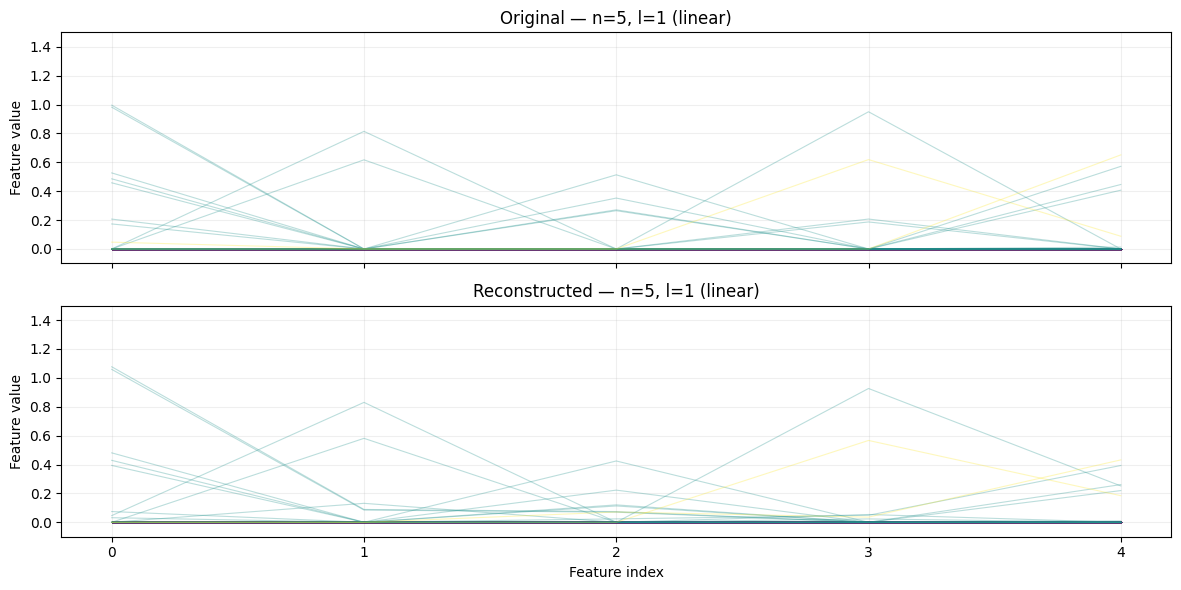

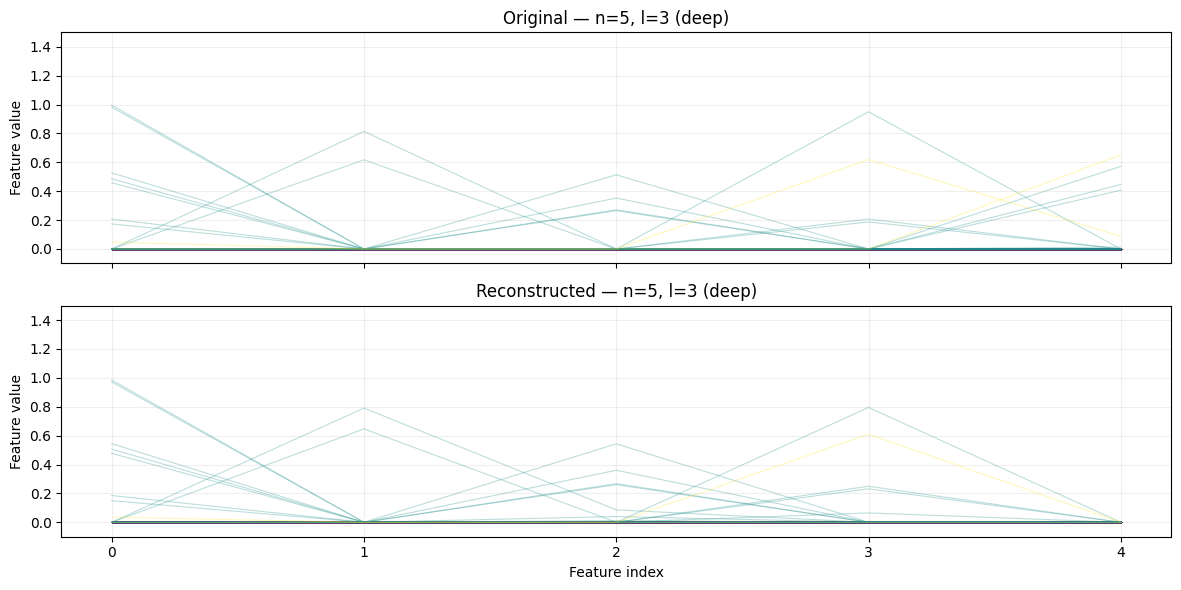

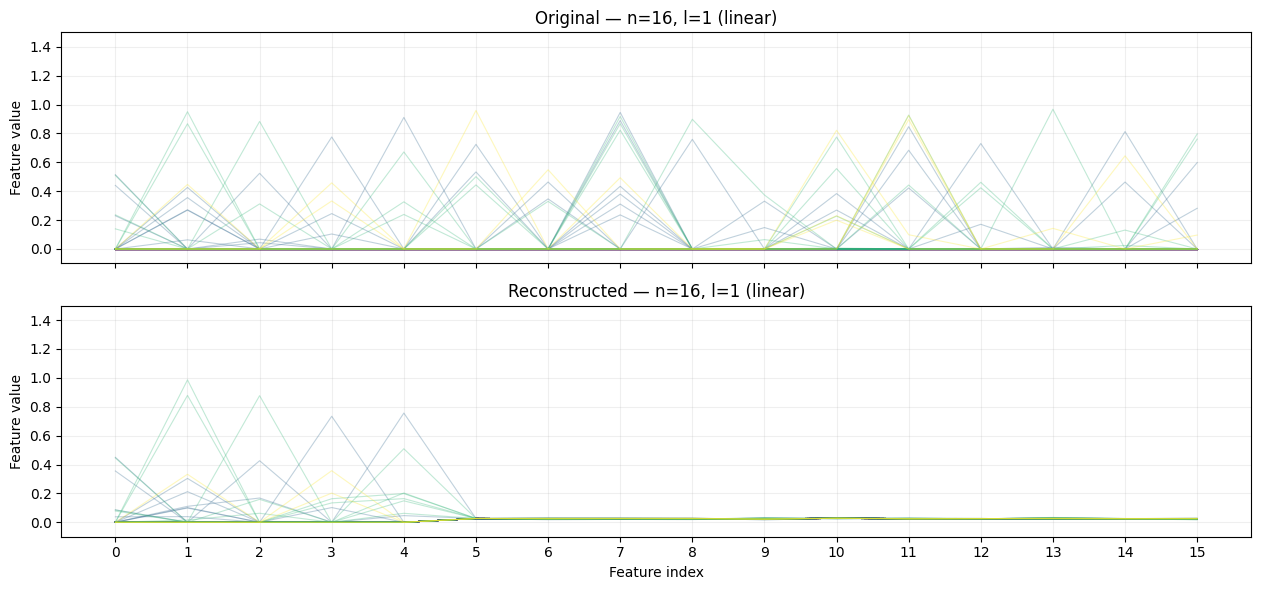

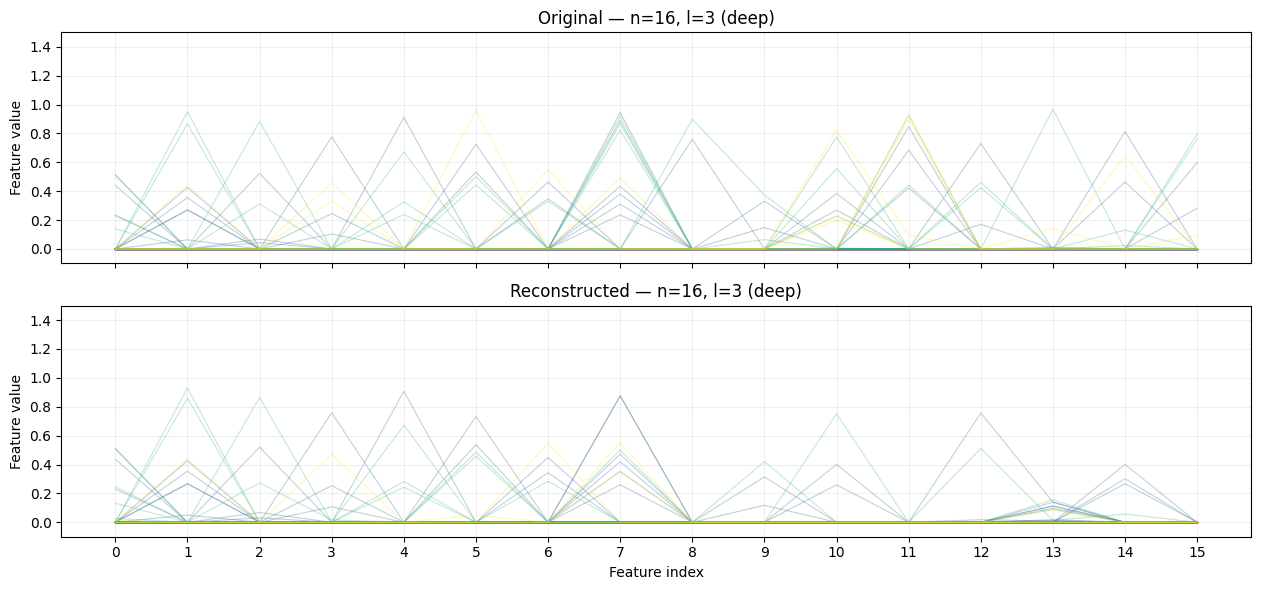

In [12]:
def plot_parallel_coordinates(cfg, results, datasets, n_samples=100):
    """Parallel coordinates: original vs reconstructed features."""
    key = cfg['label']
    n = cfg['n']
    model = results[key]['model']
    x_np = datasets[n][:n_samples]
    
    model.eval()
    with torch.no_grad():
        x_t = torch.tensor(x_np, dtype=torch.float32, device=device)
        x_recon = model(x_t)[0].cpu().numpy()
    
    fig, axes = plt.subplots(2, 1, figsize=(max(12, n * 0.8), 6), sharex=True)
    
    # Sort samples by number of active features for visual clarity
    n_active = (x_np > 0).sum(axis=1)
    order = np.argsort(n_active)
    
    for ax, data, title in [(axes[0], x_np[order], 'Original'),
                             (axes[1], x_recon[order], 'Reconstructed')]:
        for i in range(len(data)):
            c = plt.cm.viridis(n_active[order[i]] / max(n_active.max(), 1))
            ax.plot(range(n), data[i], color=c, alpha=0.3, linewidth=0.8)
        ax.set_ylabel('Feature value')
        ax.set_title(f'{title} — {key}')
        ax.set_ylim(-0.1, 1.5)
        ax.grid(True, alpha=0.2)
    
    axes[1].set_xlabel('Feature index')
    axes[1].set_xticks(range(n))
    plt.tight_layout()
    plt.show()

# Show for a couple configs
for cfg in configs:
    plot_parallel_coordinates(cfg, results, datasets)

## 8. Feature activation heatmap: which features "know about" which?

For each input feature $e_i$, encode it and decode it back. The reconstruction shows what the autoencoder thinks $e_i$ looks like — cross-talk reveals superposition structure. Compare with PCA.

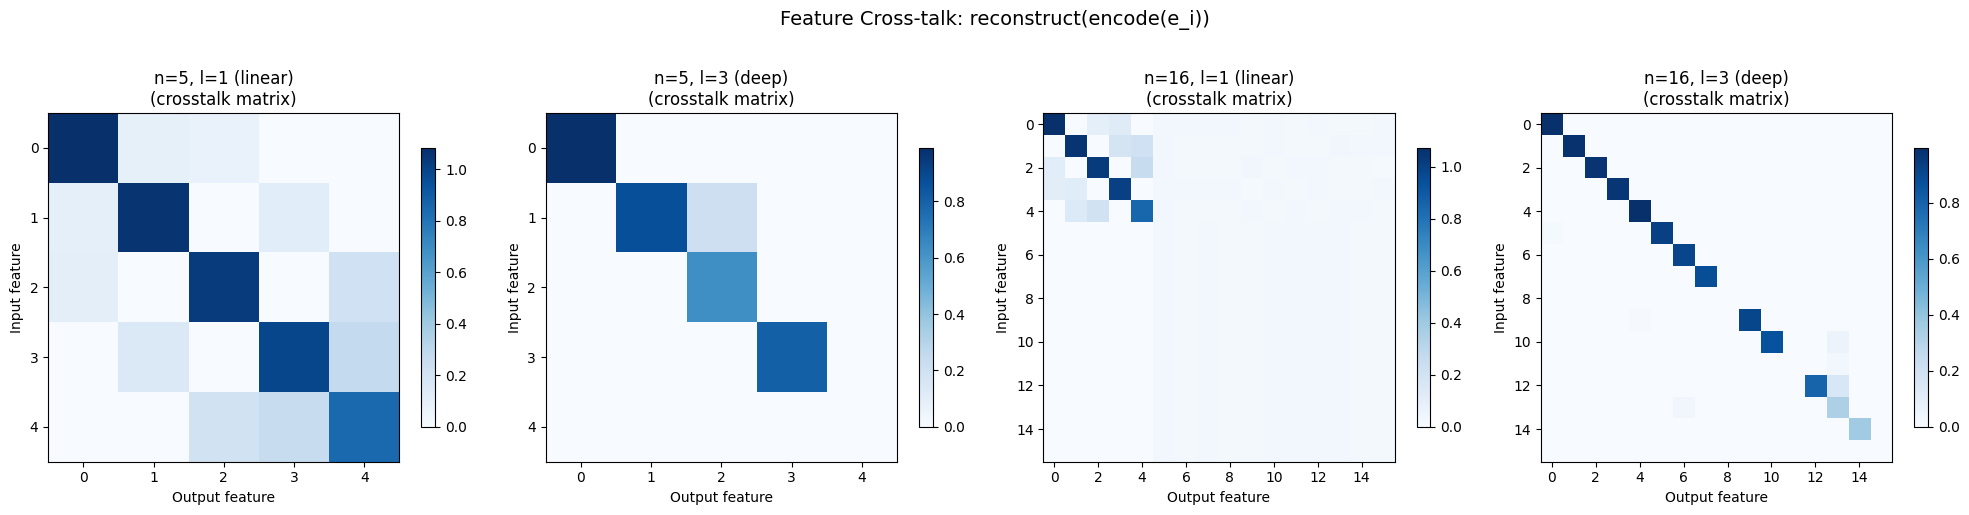

In [13]:
def plot_crosstalk_heatmaps(configs, results):
    """Heatmap: when we encode and decode e_i, what features get activated?"""
    n_cfgs = len(configs)
    fig, axes = plt.subplots(1, n_cfgs, figsize=(5 * n_cfgs, 5))
    if n_cfgs == 1:
        axes = [axes]
    
    for idx, cfg in enumerate(configs):
        key = cfg['label']
        n = cfg['n']
        model = results[key]['model']
        
        # Encode and decode each unit vector
        model.eval()
        with torch.no_grad():
            eye = torch.eye(n, device=device)
            recon = model(eye)[0].cpu().numpy()
        
        # recon[i, j] = how much feature j activates when we input pure feature i
        ax = axes[idx]
        im = ax.imshow(recon, cmap='Blues', aspect='auto', vmin=0)
        ax.set_xlabel('Output feature')
        ax.set_ylabel('Input feature')
        ax.set_title(f'{key}\n(crosstalk matrix)')
        fig.colorbar(im, ax=ax, shrink=0.8)
    
    fig.suptitle('Feature Cross-talk: reconstruct(encode(e_i))', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_crosstalk_heatmaps(configs, results)

## 9. Distance distortion analysis

Quantify how much each method distorts pairwise distances. This gets at the core difference: the autoencoder can sacrifice distance preservation for better reconstruction.

Config                    Method       Spearman r   Mean distortion
-----------------------------------------------------------------
n=5, l=1 (linear)         Autoencoder  0.9941       0.0381
n=5, l=1 (linear)         t-SNE        0.8141       0.1361
n=5, l=1 (linear)         UMAP         0.8374       0.1901

n=5, l=3 (deep)           Autoencoder  0.9551       0.0930
n=5, l=3 (deep)           t-SNE        0.8141       0.1361
n=5, l=3 (deep)           UMAP         0.8374       0.1901

n=16, l=1 (linear)        Autoencoder  0.7302       0.1761
n=16, l=1 (linear)        t-SNE        0.5372       0.1916
n=16, l=1 (linear)        UMAP         0.4104       0.2753

n=16, l=3 (deep)          Autoencoder  0.6844       0.1995
n=16, l=3 (deep)          t-SNE        0.5372       0.1916
n=16, l=3 (deep)          UMAP         0.4104       0.2753



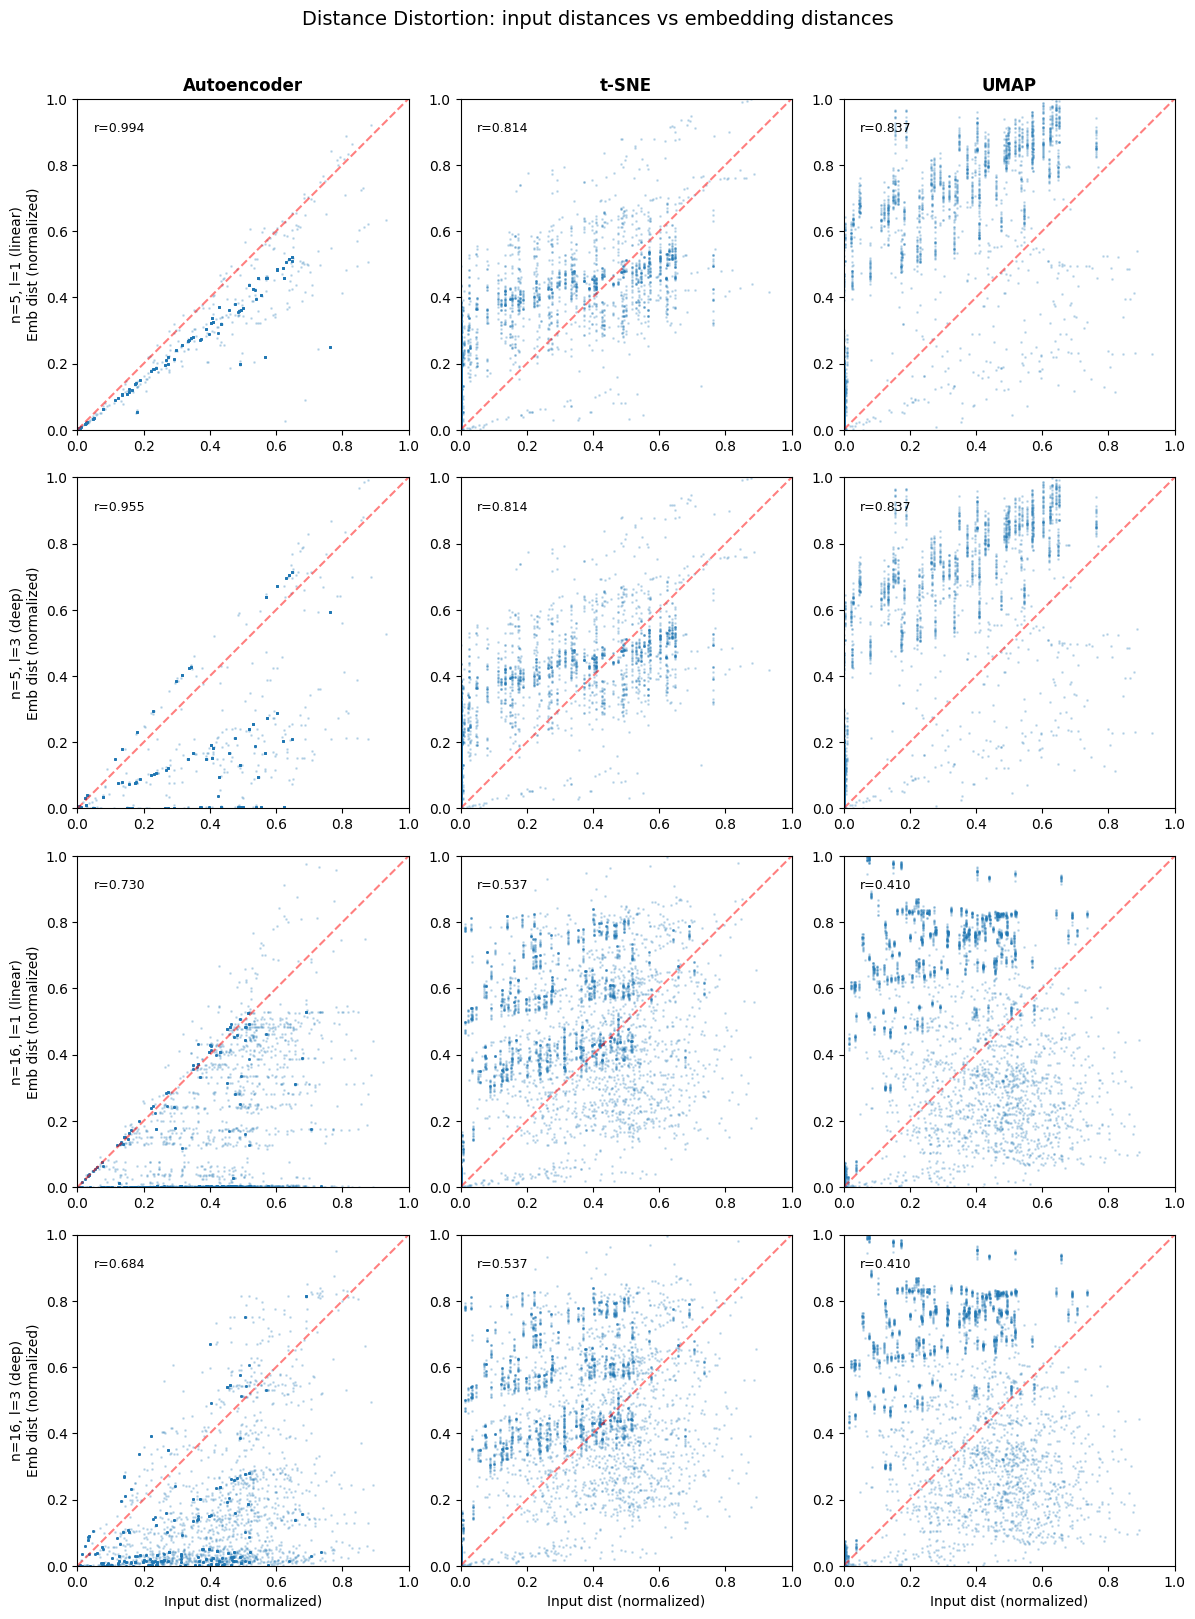

In [14]:
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

def distance_distortion_analysis(configs, all_embeddings, datasets, n_sub=300):
    """Compare pairwise distance preservation across methods."""
    methods = ['Autoencoder', 't-SNE']
    if HAS_UMAP:
        methods.append('UMAP')
    
    fig, axes = plt.subplots(len(configs), len(methods), figsize=(4*len(methods), 4*len(configs)))
    if len(configs) == 1:
        axes = axes[np.newaxis, :]
    
    print(f"{'Config':<25} {'Method':<12} {'Spearman r':<12} {'Mean distortion'}")
    print('-' * 65)
    
    for i, cfg in enumerate(configs):
        key = cfg['label']
        x_np = datasets[cfg['n']][:n_sub]
        d_orig = pdist(x_np)
        
        for j, method in enumerate(methods):
            z = all_embeddings[key][method]['z'][:n_sub]
            d_emb = pdist(z)
            
            # Normalize distances for comparison
            d_orig_n = d_orig / (d_orig.max() + 1e-10)
            d_emb_n = d_emb / (d_emb.max() + 1e-10)
            
            rho, _ = spearmanr(d_orig_n, d_emb_n)
            distortion = np.mean(np.abs(d_orig_n - d_emb_n))
            
            ax = axes[i, j]
            # Subsample for plotting
            plot_idx = np.random.RandomState(0).choice(len(d_orig_n), min(5000, len(d_orig_n)), replace=False)
            ax.scatter(d_orig_n[plot_idx], d_emb_n[plot_idx], s=1, alpha=0.2, rasterized=True)
            ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
            ax.set_aspect('equal')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            
            if i == 0:
                ax.set_title(method, fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f'{key}\nEmb dist (normalized)')
            if i == len(configs) - 1:
                ax.set_xlabel('Input dist (normalized)')
            ax.text(0.05, 0.9, f'r={rho:.3f}', transform=ax.transAxes, fontsize=9)
            
            print(f"{key:<25} {method:<12} {rho:<12.4f} {distortion:.4f}")
        print()
    
    fig.suptitle('Distance Distortion: input distances vs embedding distances', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

distance_distortion_analysis(configs, all_embeddings, datasets)

## 10. Summary

### Methodological notes

- **t-SNE has no out-of-sample transform.** Any comparison that fits t-SNE on all data then splits train/test is data leakage. Section 5 excludes t-SNE for this reason. Sections 3, 6, 9 use t-SNE on the full dataset (no train/test split), which is valid for visualization and distance/neighborhood metrics.

- **Zero-vector inflation.** At S=0.95, 43-77% of samples are the zero vector. These trivially share neighbors in any embedding, inflating neighborhood preservation for methods that keep the origin compact (AE) and penalizing methods that spread points uniformly (t-SNE, UMAP). Section 6 shows both all-data and non-zero-only results.

### Findings

1. **Reconstruction**: With the same MLP decoder, the AE embedding reconstructs best (it was optimized for this). UMAP embeddings are harder to decode than AE.

2. **Neighborhood preservation** (non-zero samples, n=16): t-SNE > UMAP > AE. t-SNE and UMAP do what they're designed for — the all-data results that show the opposite are an artifact of zero-vector clustering.

3. **Depth**: l=3 only helps at n/m >= 4. At n=5/m=2 (ratio 2.5), the linear encoder + nonlinear decoder is already sufficient; extra depth hurts via optimization difficulty.

In [15]:
# Summary table with both all-data and non-zero neighborhood preservation
import pandas as pd

methods = ['Autoencoder', 't-SNE']
if HAS_UMAP:
    methods.append('UMAP')

summary_rows = []
for cfg in configs:
    key = cfg['label']
    x_np = datasets[cfg['n']]
    nz_mask = x_np.sum(axis=1) > 0
    x_nz = x_np[nz_mask]
    
    for method in methods:
        z = all_embeddings[key][method]['z']
        row = {
            'config': key,
            'method': method,
            'nbr_k10_all': neighborhood_preservation(x_np, z, k=10),
            'nbr_k10_nonzero': neighborhood_preservation(x_nz, z[nz_mask], k=10),
        }
        if 'recon_err' in all_embeddings[key][method]:
            row['native_recon_mse'] = np.mean(all_embeddings[key][method]['recon_err'])
        summary_rows.append(row)

df = pd.DataFrame(summary_rows)
print(df.to_string(index=False))

            config      method  nbr_k10_all  nbr_k10_nonzero  native_recon_mse
 n=5, l=1 (linear) Autoencoder       0.8030         0.918202          0.001878
 n=5, l=1 (linear)       t-SNE       0.4564         0.887061               NaN
 n=5, l=1 (linear)        UMAP       0.1848         0.807675               NaN
   n=5, l=3 (deep) Autoencoder       0.7916         0.837061          0.004462
   n=5, l=3 (deep)       t-SNE       0.4564         0.887061               NaN
   n=5, l=3 (deep)        UMAP       0.1848         0.807675               NaN
n=16, l=1 (linear) Autoencoder       0.7096         0.508800          0.011919
n=16, l=1 (linear)       t-SNE       0.5130         0.762600               NaN
n=16, l=1 (linear)        UMAP       0.3738         0.669000               NaN
  n=16, l=3 (deep) Autoencoder       0.7048         0.578000          0.006884
  n=16, l=3 (deep)       t-SNE       0.5130         0.762600               NaN
  n=16, l=3 (deep)        UMAP       0.3738         